<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/classification/experiment_logistic_regression_probabilistic_classification_calibration_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# LEVEL 1: PROBABILISTIC CLASSIFICATION
# ============================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Data
X = np.random.randn(1000, 2)
y = (X[:,0] + X[:,1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Probabilities
probs = model.predict_proba(X_test)

print("First 5 probability outputs:\n", probs[:5])

First 5 probability outputs:
 [[9.74092459e-01 2.59075414e-02]
 [3.74265973e-01 6.25734027e-01]
 [6.94018635e-03 9.93059814e-01]
 [9.99244091e-01 7.55909343e-04]
 [9.68419002e-01 3.15809985e-02]]


In [2]:
threshold = 0.7

preds_custom = (probs[:,1] > threshold).astype(int)

print("Custom predictions:", preds_custom[:10])

Custom predictions: [0 0 1 0 0 1 1 0 1 1]


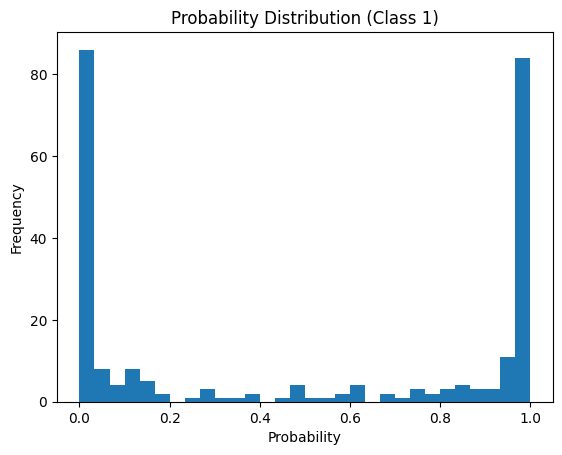

In [3]:
import matplotlib.pyplot as plt

plt.hist(probs[:,1], bins=30)
plt.title("Probability Distribution (Class 1)")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

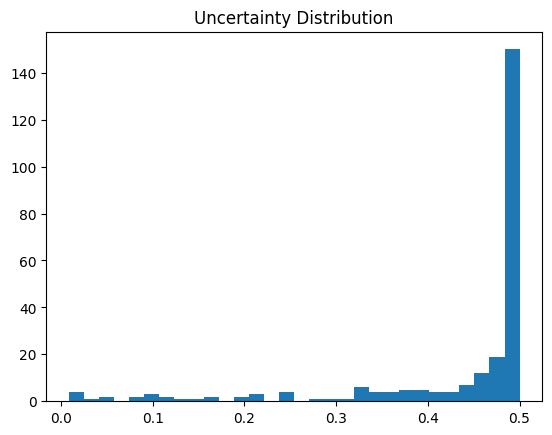

In [4]:
uncertainty = np.abs(probs[:,1] - 0.5)

plt.hist(uncertainty, bins=30)
plt.title("Uncertainty Distribution")
plt.show()

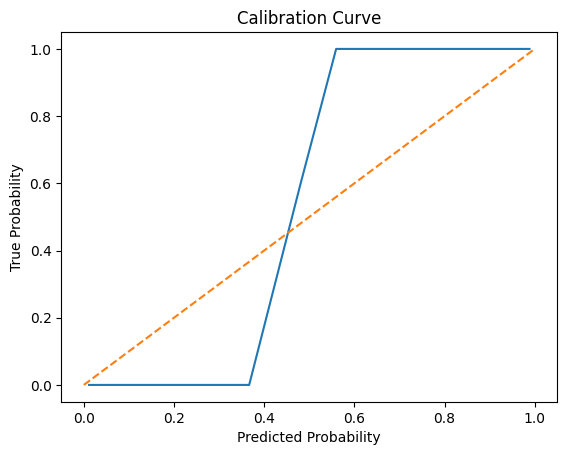

In [5]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, probs[:,1], n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1], [0,1], '--')

plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")

plt.show()